In [ ]:
from notebook_setup import setup
env = setup()

from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/scripts


In [3]:
from pathlib import Path 
from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings
# find_closest_connectome, plot_connectome, compare_orderings

import networkx as nx
import torch

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import numpy as np

In [5]:
import warnings
import scipy
import networkx as nx
import seaborn as sns
import utils as ut
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

from tqdm import tqdm
from msapy import msa

from IPython.display import HTML

from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist, squareform, cosine
from scipy.special import factorial

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LinearRegression, LassoCV

from netneurotools.metrics import (
    communicability_wei,
    communicability_bin,
    distance_wei_floyd,
)

from kaysons_visual_config import * # Kayson's file. 
from matplotlib import font_manager


for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

In [159]:
# # get range of gamma 
# range_gamma = df["gamma"].max()-df["gamma"].min()
# range_eta = df["eta"].max()-df["eta"].min()
# # Get scaling factor
# scaling_factor = 0.5/range_eta*range_gamma

In [182]:
experiment_name = "76_90000_samples_animal_206" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset") / experiment_name

data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
data_dir.mkdir(parents=True, exist_ok=True)

margin_x = 0.5
margin_y = 0.05
interesting_eta_and_gamma_combinations = [
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.8, 0.18],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-5, 0.5],
    
    # [-8, 1],  
    # [3, 1], 
    # [0, 0.18],
    # [3, -0.1], 
    # [-8, -0.1],
    # [-5.25, 0.4],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    connectomes.append(connectome)
    params.append((found_eta, found_gamma))
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)


Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-7.484950065612793_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (-7.5, 0.95)
Found  (η, γ): (-7.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta2.484949827194214_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (2.5, 0.95)
Found  (η, γ): (2.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-0.789297699928284_gamma0.179598659276962_ruleMatchingIndex_id000.npy
Target (η, γ): (-0.8, 0.18)
Found  (η, γ): (-0.789, 0.180)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/o

In [183]:
import pandas as pd

# Load the metrics data
metrics_csv_path = base_path / f"all_metrics_for_{experiment_name}.csv"
gnm_results_df = pd.read_csv(metrics_csv_path, index_col=False)

# Prepare data for MaxCriteria metric
df = gnm_results_df.copy()
df["eta"] = pd.to_numeric(df["eta"], errors='coerce')
df["gamma"] = pd.to_numeric(df["gamma"], errors='coerce')

# Find the MaxCriteria column
metric_col_name = next(col for col in df.columns if "MaxCriteria" in col)
df[metric_col_name] = pd.to_numeric(df[metric_col_name], errors='coerce')
df = df.dropna(subset=['eta', 'gamma', metric_col_name])


# BINNING
BINNING = False 
if BINNING: 
    # bin the eta and gamma values into 100 bins each
    df['eta'] = pd.cut(df['eta'], bins=100)
    df['gamma'] = pd.cut(df['gamma'], bins=100)

# PIVOTING
# Pivot the DataFrame to create a matrix for heatmap
heatmap_data = df.pivot_table(index='gamma', columns='eta', values=metric_col_name)

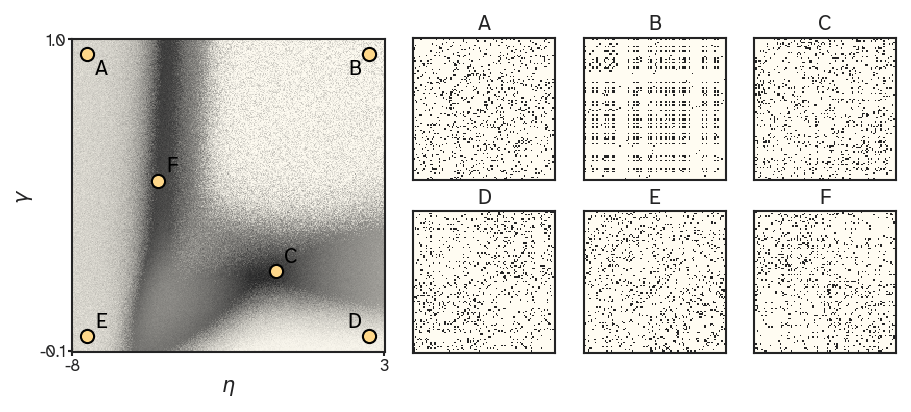

In [187]:
point_color = "#FED789FF"
fig, axes = plt.subplot_mosaic(
    [["landscape", "landscape", "A", "B", "C"], 
     ["landscape", "landscape", "D", "E", "F"]], 
    figsize=(viz.cm_to_inch((18, 7))), dpi=150
    
)

# Flip the heatmap data vertically
heatmap_data_flipped = heatmap_data.iloc[::-1]

sns.heatmap(
    heatmap_data_flipped,
    square=True,    
    xticklabels=False, 
    yticklabels=False,  
    cbar=False, # True, # False,
    cmap=default_cmaps["hb_bw"],
    ax=axes["landscape"]
)

eta_values = heatmap_data_flipped.columns # np.array([interval.mid for interval in heatmap_data_flipped.columns])
gamma_values = heatmap_data_flipped.index # np.array([interval.mid for interval in heatmap_data_flipped.index])

# Set x-axis ticks (η) - only first and last
eta_min, eta_max = eta_values.min(), eta_values.max()
x_tick_positions = [0, len(eta_values) - 1]  # First and last positions
x_tick_labels = [f"{eta_min:.1f}" if eta_min % 1 != 0 else f"{int(eta_min)}", 
                 f"{eta_max:.1f}" if eta_max % 1 != 0 else f"{int(eta_max)}"]
axes["landscape"].set_xticks(x_tick_positions)
axes["landscape"].set_xticklabels(x_tick_labels)

# Set y-axis ticks (γ) - only first and last
gamma_min, gamma_max = gamma_values.min(), gamma_values.max()
y_tick_positions = [0, len(gamma_values) - 1]  # First and last positions
y_tick_labels = [f"{gamma_max:.1f}", f"{gamma_min:.1f}"]  # Note: reversed because data is flipped
axes["landscape"].set_yticks(y_tick_positions)
axes["landscape"].set_yticklabels(y_tick_labels, rotation=0)



# # Create nice number ticks for x-axis (η)
# eta_values = heatmap_data_flipped.columns # np.array([interval.mid for interval in heatmap_data_flipped.columns])
# nice_eta = np.arange(np.ceil(eta_values.min()), np.floor(eta_values.max()) + 0.5, 1.8)
# eta_ticks = [np.argmin(np.abs(eta_values - val)) for val in nice_eta]
# axes["landscape"].set_xticks(eta_ticks)
# axes["landscape"].set_xticklabels([f"{val:.1f}" if val % 1 != 0 else f"{int(val)}" for val in nice_eta])

# # Create nice number ticks for y-axis (γ)
# gamma_values = heatmap_data_flipped.index # np.array([interval.mid for interval in heatmap_data_flipped.index])
# nice_gamma = np.arange(np.ceil(gamma_values.min() * 10) / 10, np.floor(gamma_values.max() * 10) / 10 + 0.1, 0.3) # 0.1)
# gamma_ticks = [np.argmin(np.abs(gamma_values - val)) for val in nice_gamma]
# axes["landscape"].set_yticks(gamma_ticks)
# axes["landscape"].set_yticklabels([f"{val:.1f}" for val in nice_gamma], rotation=0)

# Set axis labels
axes["landscape"].set_xlabel(r"$\eta$") 
axes["landscape"].set_ylabel(r"$\gamma$") 

# Flip the y-axis to have low gamma at bottom
eta_values = heatmap_data_flipped.columns
gamma_values = heatmap_data_flipped.index

scatter_x = []
scatter_y = []

for combo in interesting_eta_and_gamma_combinations:
    target_eta = combo[0]
    target_gamma = combo[1]
    
    # Find closest indices in the heatmap
    x_idx = np.argmin(np.abs(eta_values - target_eta))
    y_idx = np.argmin(np.abs(gamma_values - target_gamma))
    
    scatter_x.append(x_idx)
    scatter_y.append(y_idx)

# Add scatter points to the landscape
axes["landscape"].scatter(
    scatter_x,
    scatter_y,
    color=point_color,
    s=40,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,  # Ensure points are on top
    label='Selected Networks'
)

# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']

############# FINETUNING THE SHIFTS #############
right = 14
left = 14
up = 14
down = 14

shifts = {
    'A': (right, down),
    'B': (-left, down),
    'C': (right, -up),
    'D': (-left, -up),
    'E': (right, -up),
    'F': (right, -up),
}
for x, y, label in zip(scatter_x, scatter_y, labels):
    shift_x, shift_y = shifts[label]
    axes["landscape"].text(x+shift_x, y+shift_y, f'{label}', # f'({label})', 
            # bbox=dict(# facecolor='white', 
            #         #   alpha=0.5
            #           ), 
            color='black', ha="center", va="center") # , fontsize=8) # , ha='right', va='bottom')


# Plot connectomes
for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F"]):
    sns.heatmap(
        connectomes[idx],
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
        cmap=default_cmaps["bw_hb"],
        ax=axes[ax_label]
    )
    found_eta, found_gamma = params[idx][0], params[idx][1]
    axes[ax_label].set_title(ax_label)
        # r"$\eta$: " + f"{np.round(found_eta)}," + r"$\gamma$: " + f"{np.round(found_gamma)}")  

sns.despine(fig=fig, top=False, right=False, left=False, bottom=False)
#plt.tight_layout()
# plt.savefig(save_dir / f"figure_1_landscape_and_connectomes.pdf", bbox_inches="tight")

# Add A and stuff -- no gamma eta 
# Remove ticks (except for the extremes) 
# Bring points a bit in 

In [ ]:

# Create the complex figure layout
fig = plt.figure(figsize=(20, 16))

# Define the grid: 4 rows, 6 columns
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)

#  a a a b c d 
#  a a a h i j    
#  k k l l m m

# Row 1 & 2: a a a (spans both rows) | b c d (row 1) and e f g (row 2)
ax_a = fig.add_subplot(gs[0:2, 0:3])  # a spans 2 rows and 3 columns
ax_b = fig.add_subplot(gs[0, 3])      # b
ax_c = fig.add_subplot(gs[0, 4])      # c
ax_d = fig.add_subplot(gs[0, 5])      # d
ax_e = fig.add_subplot(gs[1, 3])      # e
ax_f = fig.add_subplot(gs[1, 4])      # f
ax_g = fig.add_subplot(gs[1, 5])      # g

# Row 3: hh | ii | jj (each spans 2 columns)
ax_hh = fig.add_subplot(gs[2, 0:2])  # hh spans 2 columns
ax_ii = fig.add_subplot(gs[2, 2:4])  # ii spans 2 columns
ax_jj = fig.add_subplot(gs[2, 4:6])  # jj spans 2 columns

# Row 4: kk | ll | mm (each spans 2 columns)
ax_kk = fig.add_subplot(gs[3, 0:2])  # kk spans 2 columns
ax_ll = fig.add_subplot(gs[3, 2:4])  # ll spans 2 columns
ax_mm = fig.add_subplot(gs[3, 4:6])  # mm spans 2 columns




# Plot MaxCriteria metric landscape in 'a' plots using the visualizer
from src.visualization.energy_and_mc_landscape import PipelineVisualizer
import pandas as pd

# Load the metrics data
metrics_csv_path = base_path / "all_metrics_for_70_mix_and_match_animal_0.csv"
gnm_results_df = pd.read_csv(metrics_csv_path, index_col=False)

# Prepare data for MaxCriteria metric
df = gnm_results_df.copy()
df["eta"] = pd.to_numeric(df["eta"], errors='coerce')
df["gamma"] = pd.to_numeric(df["gamma"], errors='coerce')

# Find the MaxCriteria column
metric_col_name = next(col for col in df.columns if "MaxCriteria" in col)
df[metric_col_name] = pd.to_numeric(df[metric_col_name], errors='coerce')
df = df.dropna(subset=['eta', 'gamma', metric_col_name])

# Initialize visualizer
visualizer = PipelineVisualizer()

# # Plot on ax_a1 (keeping ax_a2 for potential additional content)
visualizer.plot_metric_landscape_voronoi(
    df, 
    title="Energy Landscape (MaxCriteria)",
    metric_name=metric_col_name,
    savepath=None,
    dot_color="steelblue", 
    eta_span=None, 
    gamma_span=None,
    show=False,
    show_dots=False,
    annotate_extremes=True,
    estimated_indiv_connectomes=None,
    ax=ax_a # Pass the axis to plot on
)

# Scatter interesting eta and gamma combinations onto the landscape
ax_a.scatter(
    [combo[0] for combo in interesting_eta_and_gamma_combinations],
    [combo[1] for combo in interesting_eta_and_gamma_combinations],
    color='blue',
    s=50,
    label='Selected Combinations'
)
# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for combo, label in zip(interesting_eta_and_gamma_combinations, labels):
    ax_a.text(combo[0], combo[1], f'({label})', 
              bbox=dict(facecolor='white', alpha=0.5), 
              color='black', fontsize=12, ha='right')




# Keep ax_a2 empty or use for additional info
# ax_a2.text(0.5, 0.5, 'Plot A (empty)', ha='center', va='center', fontsize=16)
# ax_a2.axis('off')


# Plot adjacency matrices in b, c, d, e, f, g
matrix_axes = [ax_b, ax_c, ax_d, ax_e, ax_f, ax_g]
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, (ax, label) in enumerate(zip(matrix_axes, labels)):
    connectome = connectomes[idx]
    im = ax.imshow(connectome, cmap='viridis', aspect='equal')
    ax.set_title(f'{label}: η={params[idx][0]:.2f}, γ={params[idx][1]:.2f}', fontsize=10)
    ax.set_xlabel('Node', fontsize=8)
    ax.set_ylabel('Node', fontsize=8)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# # Leave hh, ii, jj empty for now
# for ax, label in [(ax_hh, 'hh'), (ax_ii, 'ii'), (ax_jj, 'jj')]:
#     ax.text(0.5, 0.5, f'Plot {label} (empty)', ha='center', va='center', fontsize=14)
#     ax.axis('off')




# Plot network visualizations in kk, ll, mm (use networkx for the graphs, e.g., Kamada-Kawai layout)
# Using first 3 networks as examples
network_axes = [ax_hh, ax_ii, ax_jj, ax_kk, ax_ll, ax_mm]
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, (ax, label) in enumerate(zip(network_axes, labels)):
    # Plot network visualization here
    # For now, showing a placeholder - replace with your actual network plotting function
    connectome = connectomes[idx]
    G = nx.from_numpy_array(connectome)
    # pos = nx.kamada_kaway_layout(G)
    nx.draw(G, pos=nx.kamada_kawai_layout(G),  ax=ax, with_labels=True, node_size=50, font_size=8) 
    ax.set_title(f'{label}: Network η={params[idx][0]:.2f}, γ={params[idx][1]:.2f}', fontsize=10)
    ax.set_xlabel('Node', fontsize=8)
    ax.set_ylabel('Node', fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle('Complex Network Analysis Layout', fontsize=18, y=0.995)

# Save the figure
save_path = save_dir / "complex_subplot_layout.pdf"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved complex plot to: {save_path}")

# Save parameter combinations
import pandas as pd
df_interesting_eta_and_gamma_combinations = pd.DataFrame(
    interesting_eta_and_gamma_combinations, 
    columns=["eta", "gamma", "found_eta", "found_gamma"], 
    index=None
)
csv_path = save_dir / "evaluated_eta_and_gamma_combinations.csv"
df_interesting_eta_and_gamma_combinations.to_csv(csv_path)
print(f"Saved parameters to: {csv_path}")

plt.show()

# Older stuff


Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta-7.498466491699219_gamma0.9603278636932373_ruleMatchingIndex.npy
Target (η, γ): (-8, 1)
Found  (η, γ): (-7.498, 0.960)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-7.498_gamma0.960.png


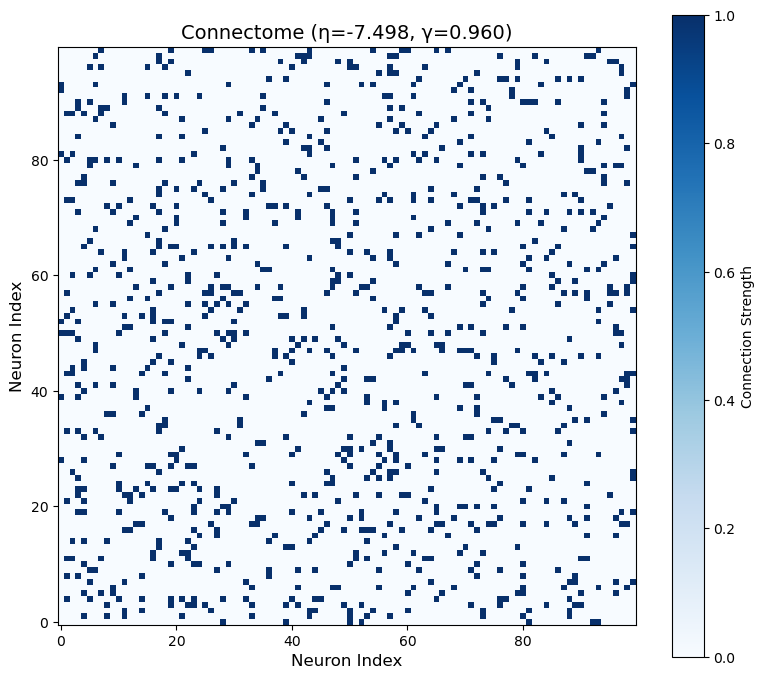

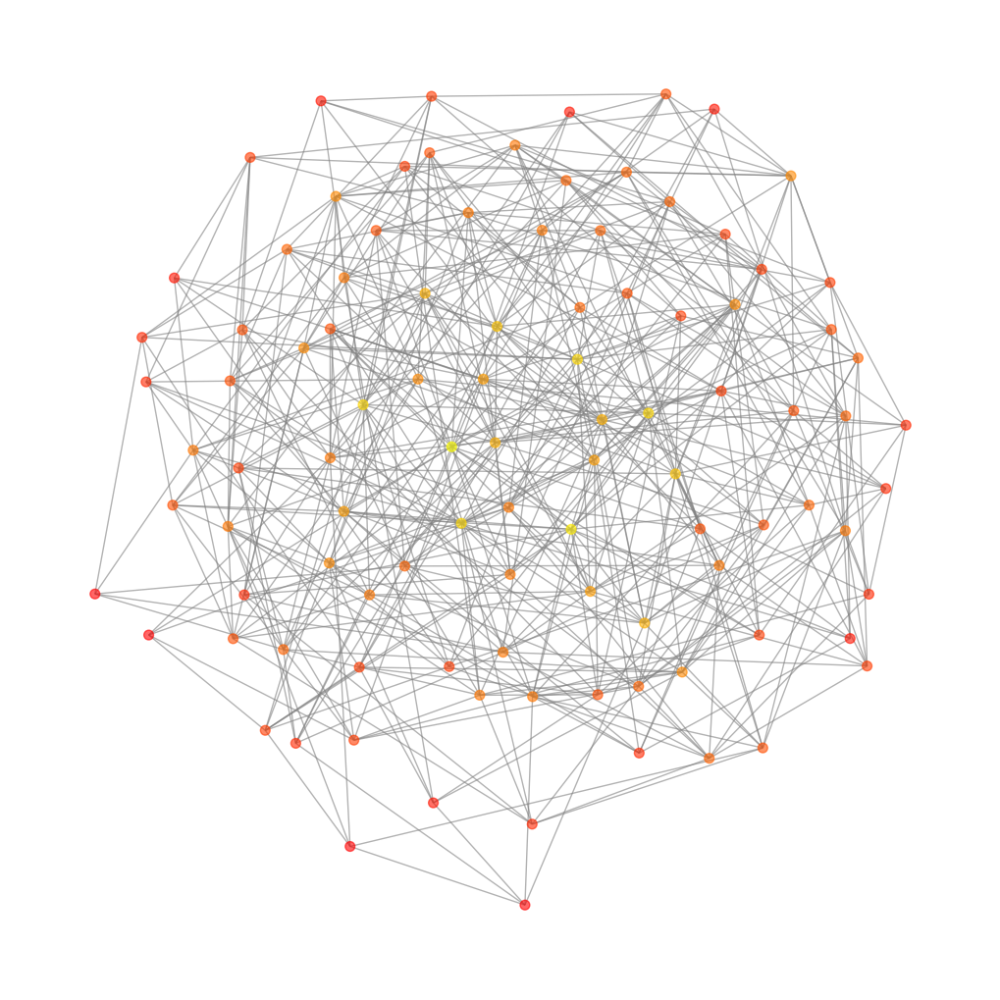

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
Processing block [50:100] with method: spectral
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-7.498_gamma0.960_spectral_blockwise.png


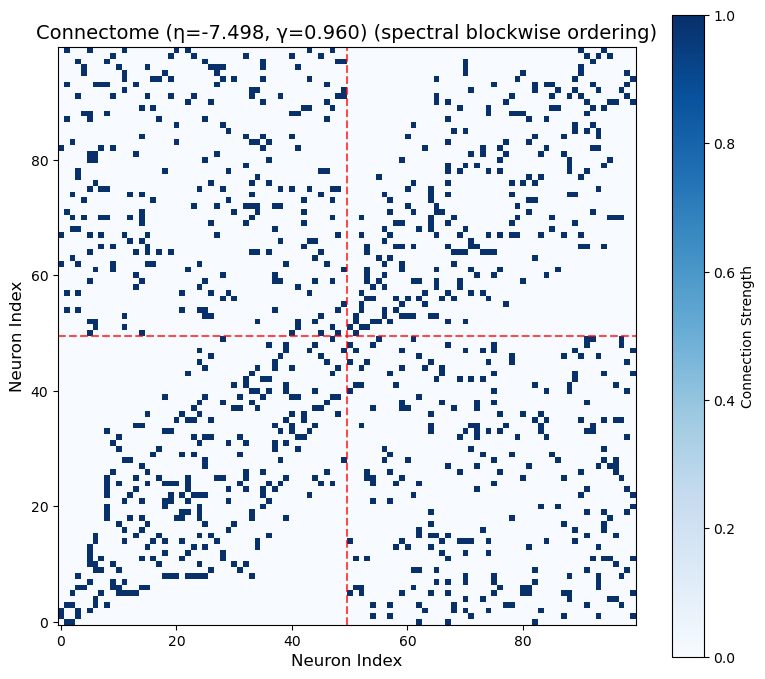

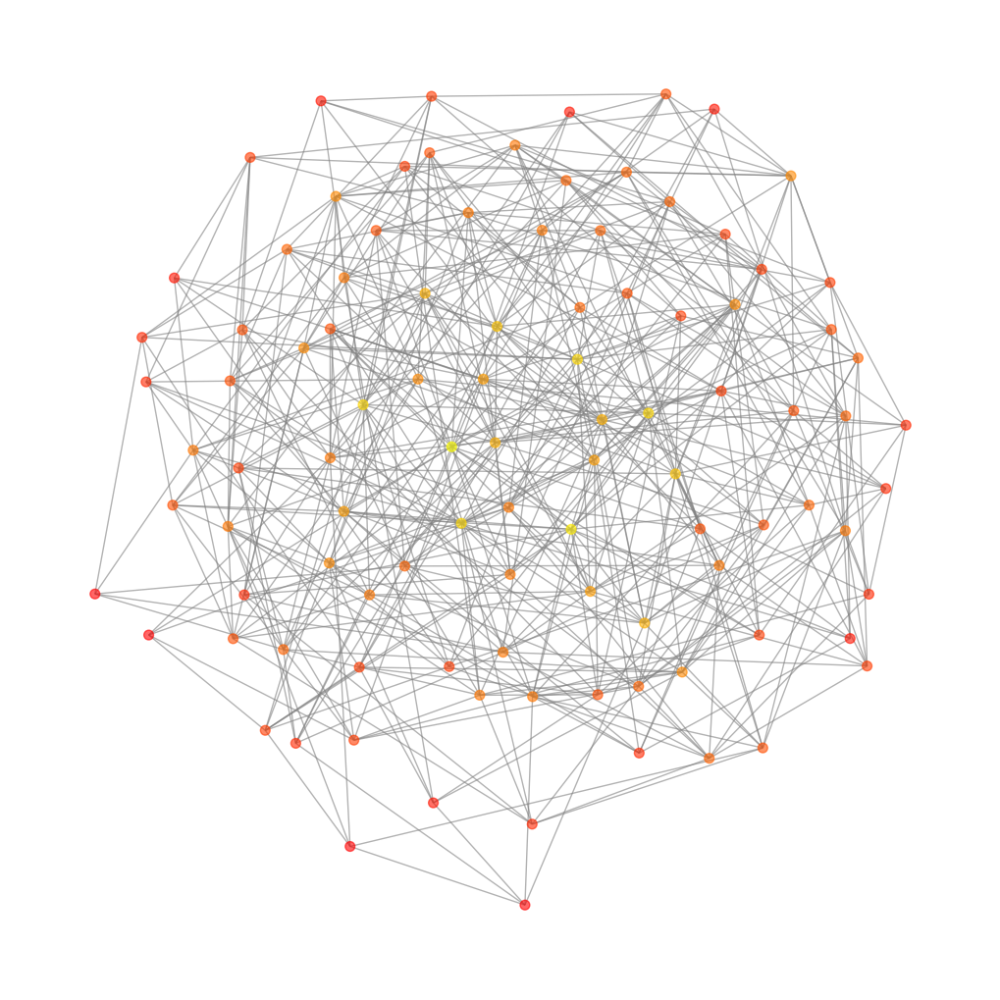

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta2.4977245330810547_gamma0.9309005737304688_ruleMatchingIndex.npy
Target (η, γ): (3, 1)
Found  (η, γ): (2.498, 0.931)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta2.498_gamma0.931.png


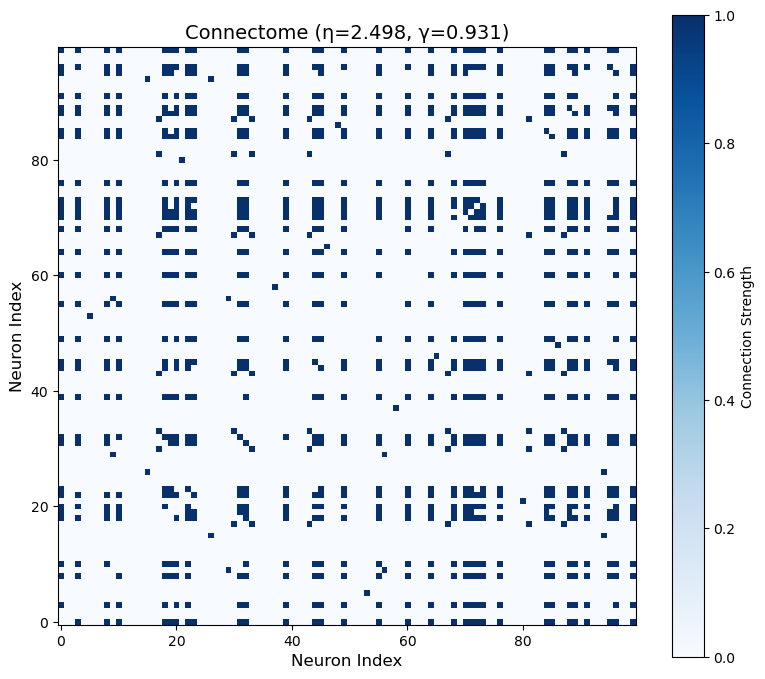

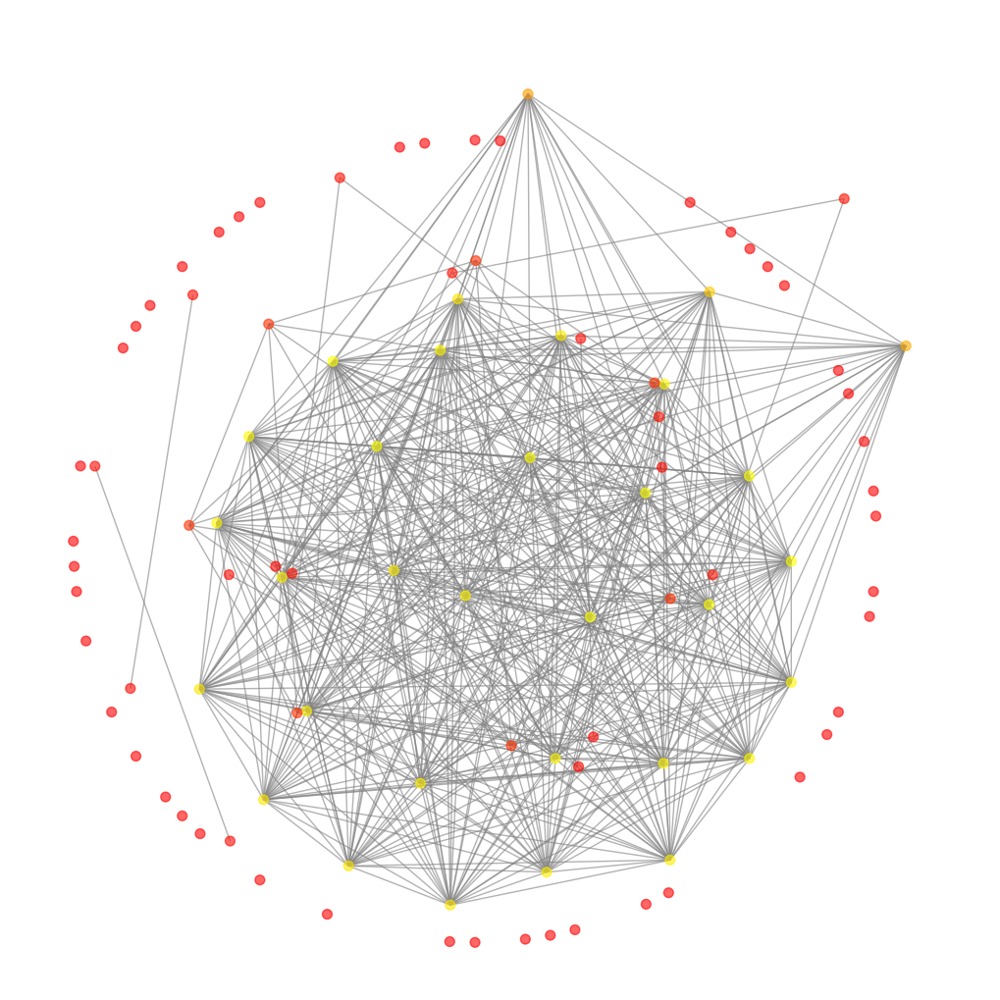

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
  Block [0:50] is disconnected, using degree ordering
Processing block [50:100] with method: spectral
  Block [50:100] is disconnected, using degree ordering
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta2.498_gamma0.931_spectral_blockwise.png


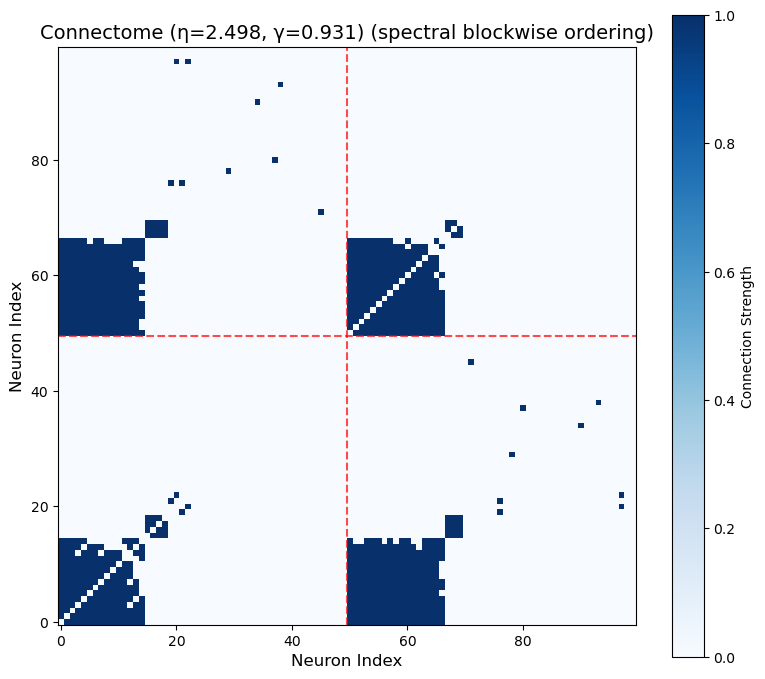

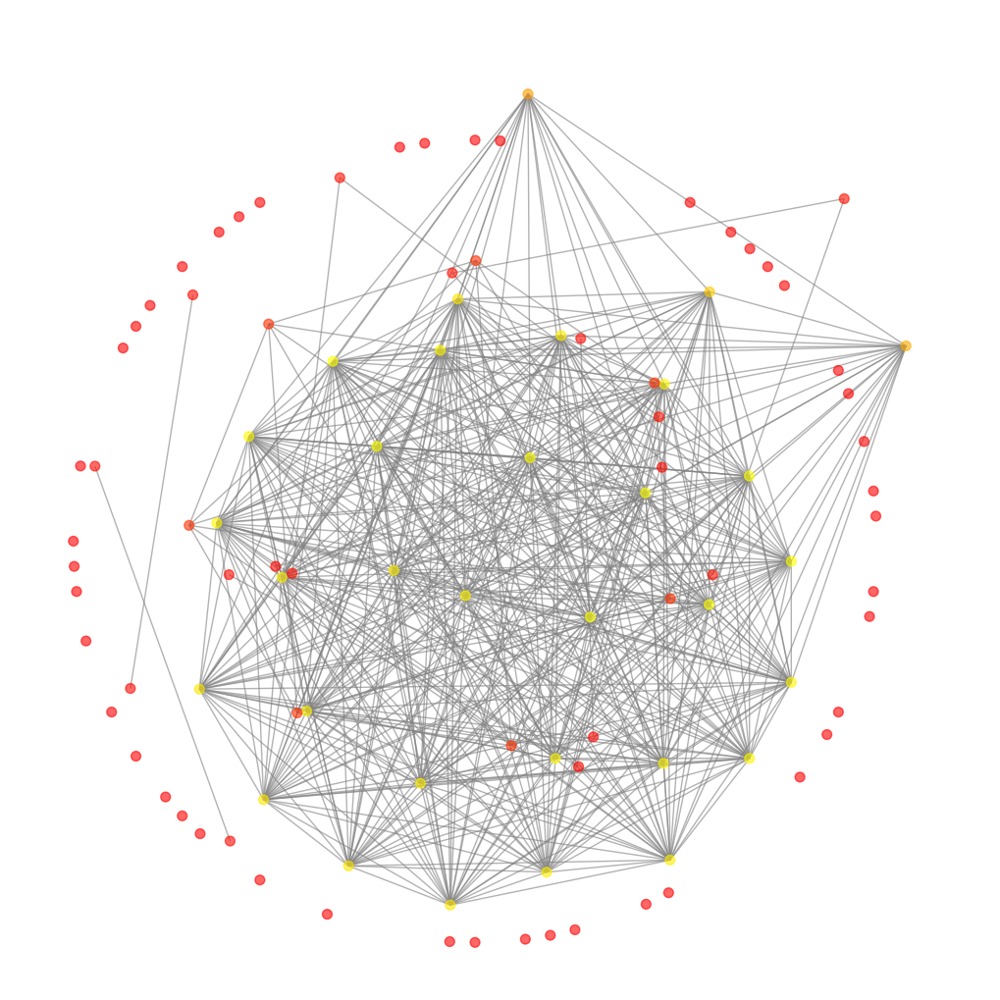

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta-0.030540943145751953_gamma0.9965962171554565_ruleMatchingIndex.npy
Target (η, γ): (0, 1.8)
Found  (η, γ): (-0.031, 0.997)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-0.031_gamma0.997.png


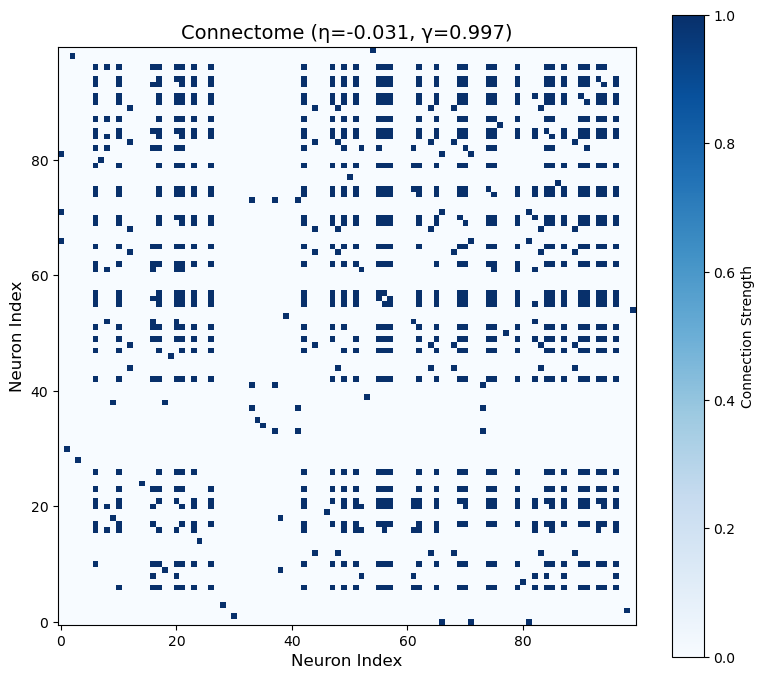

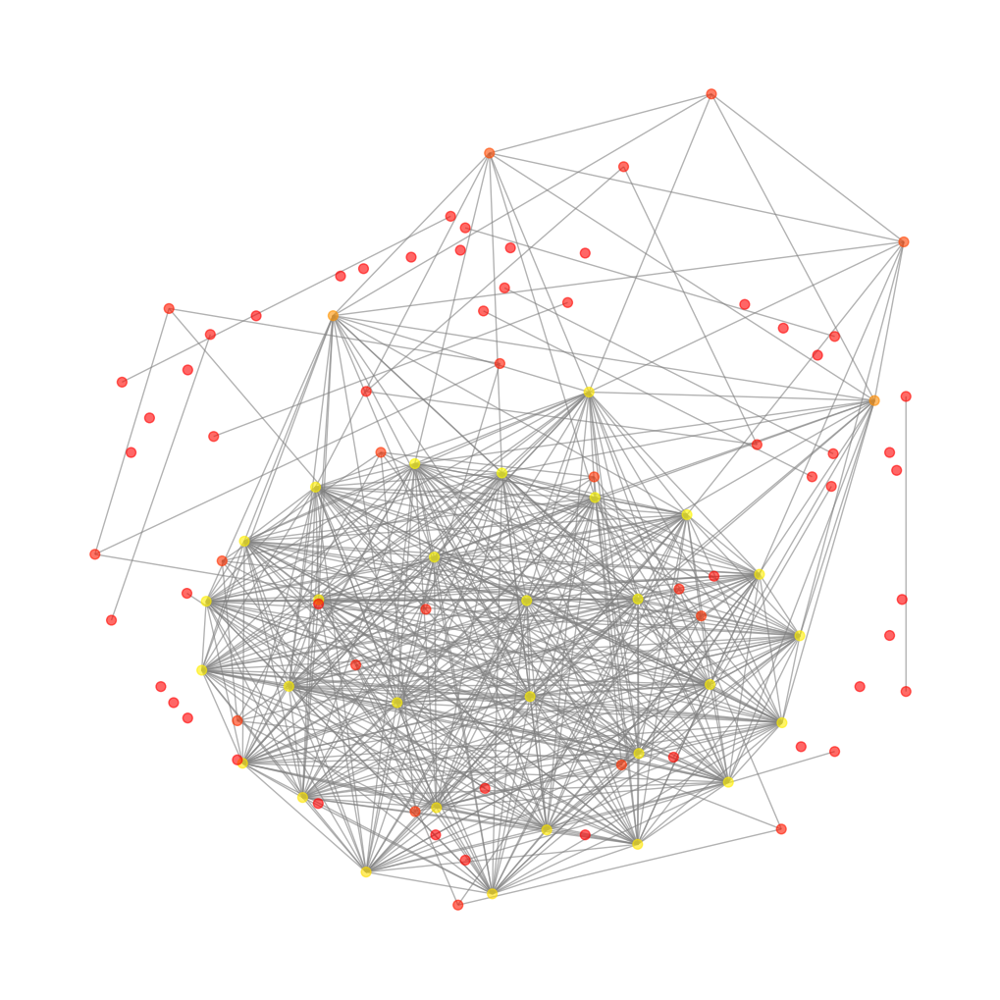

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
  Block [0:50] is disconnected, using degree ordering
Processing block [50:100] with method: spectral
  Block [50:100] is disconnected, using degree ordering
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-0.031_gamma0.997_spectral_blockwise.png


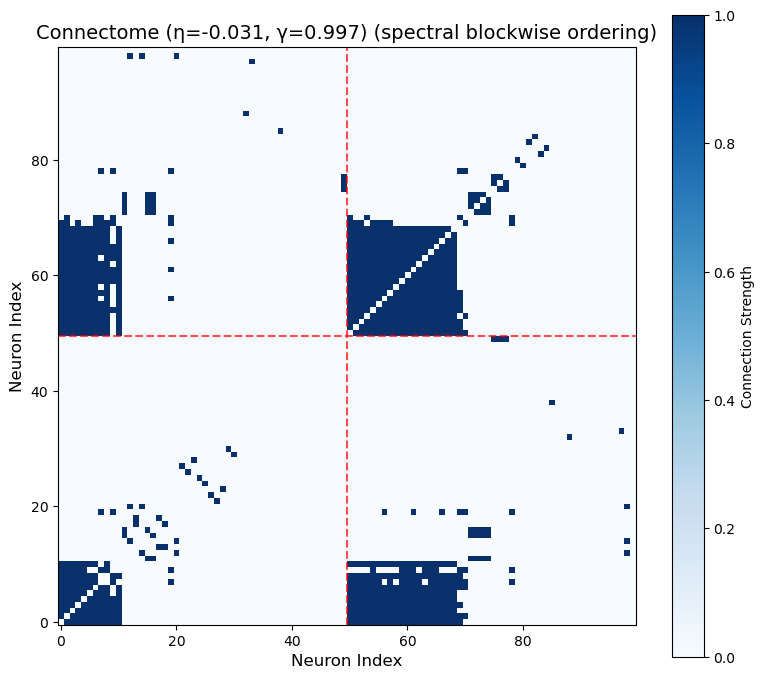

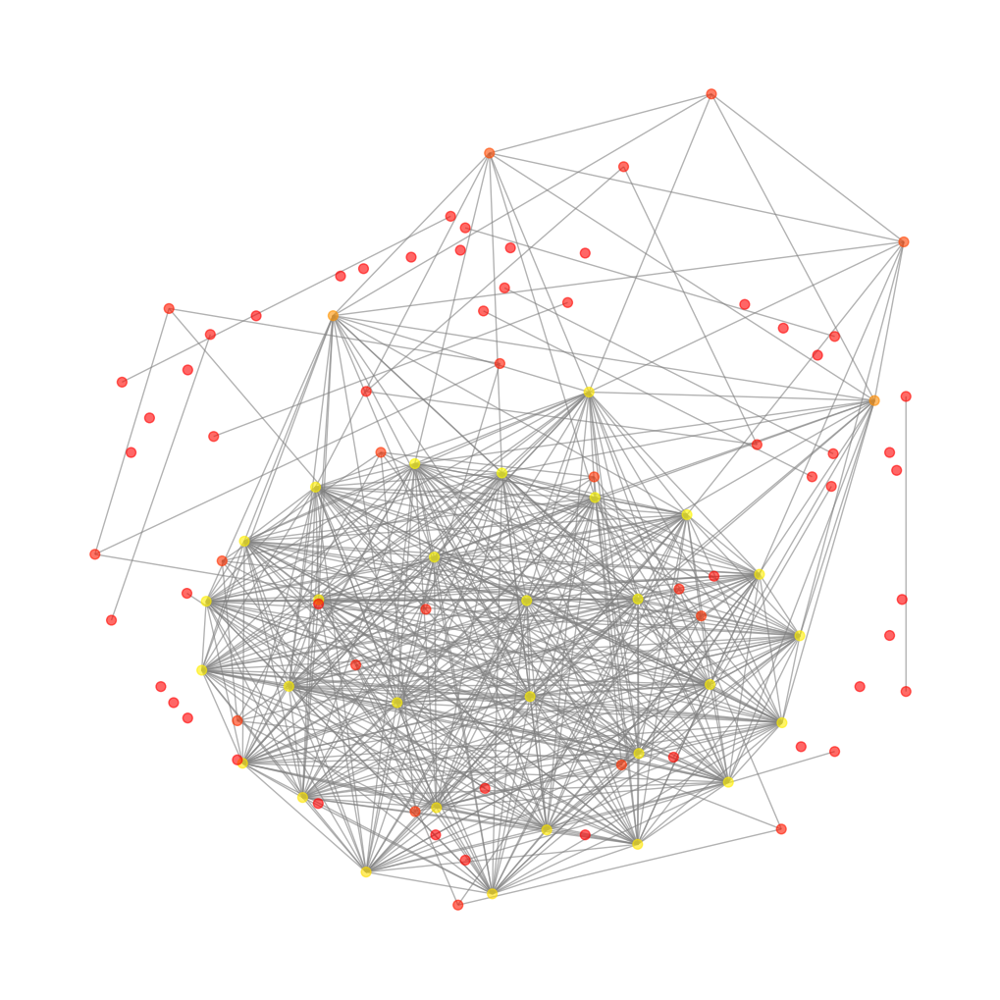

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta3.0102040767669678_gamma0.0_ruleMatchingIndex.npy
Target (η, γ): (3, -0.1)
Found  (η, γ): (3.010, 0.000)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta3.010_gamma0.000.png


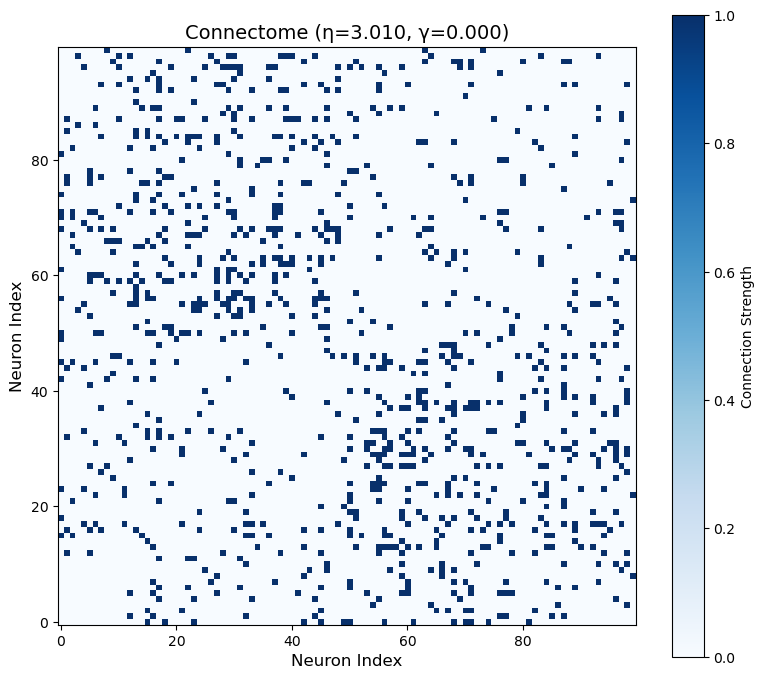

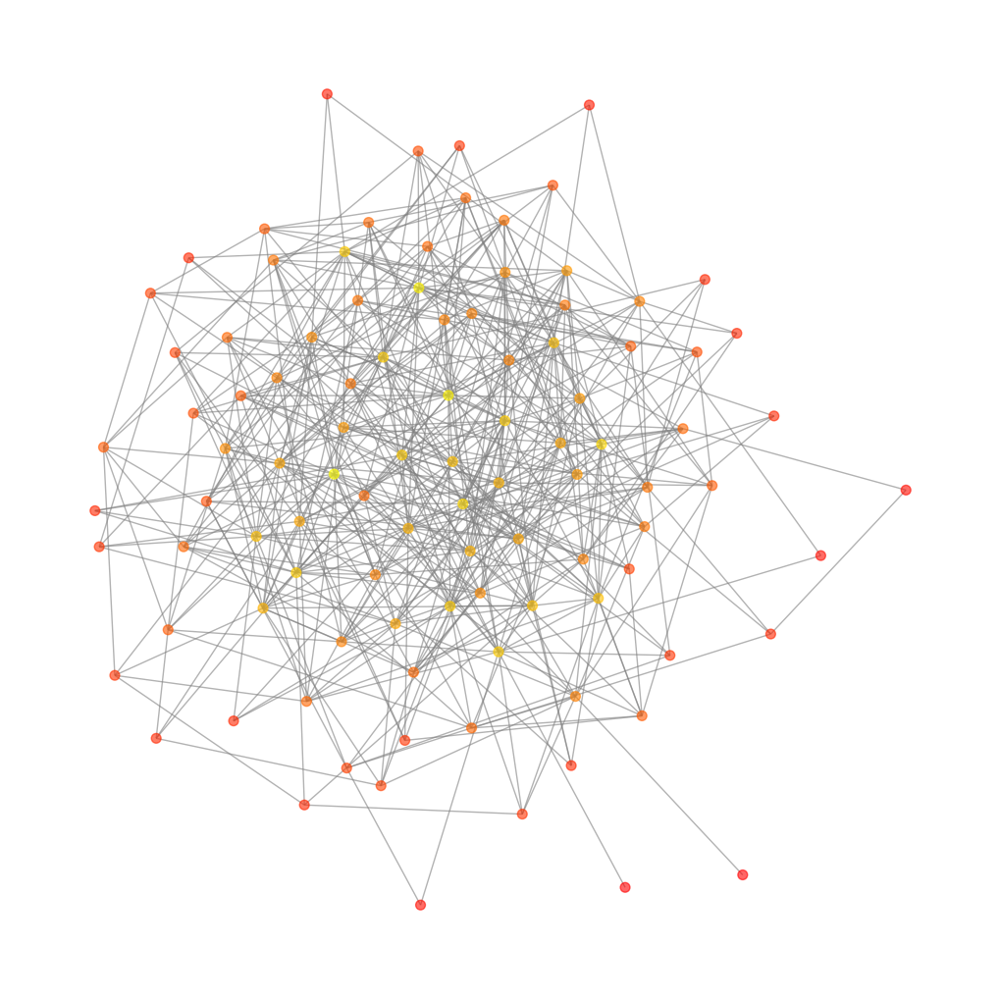

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
  Block [0:50] is disconnected, using degree ordering
Processing block [50:100] with method: spectral
  Block [50:100] is disconnected, using degree ordering
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta3.010_gamma0.000_spectral_blockwise.png


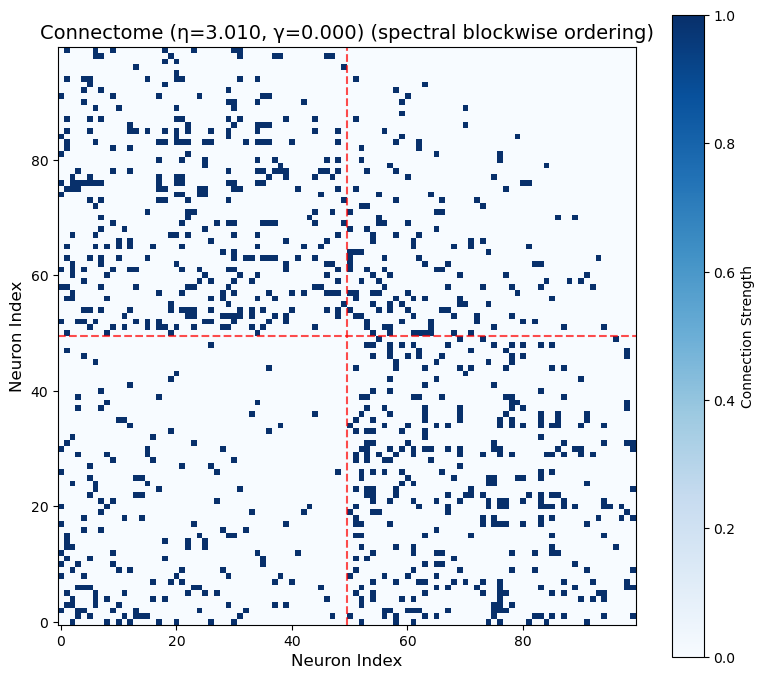

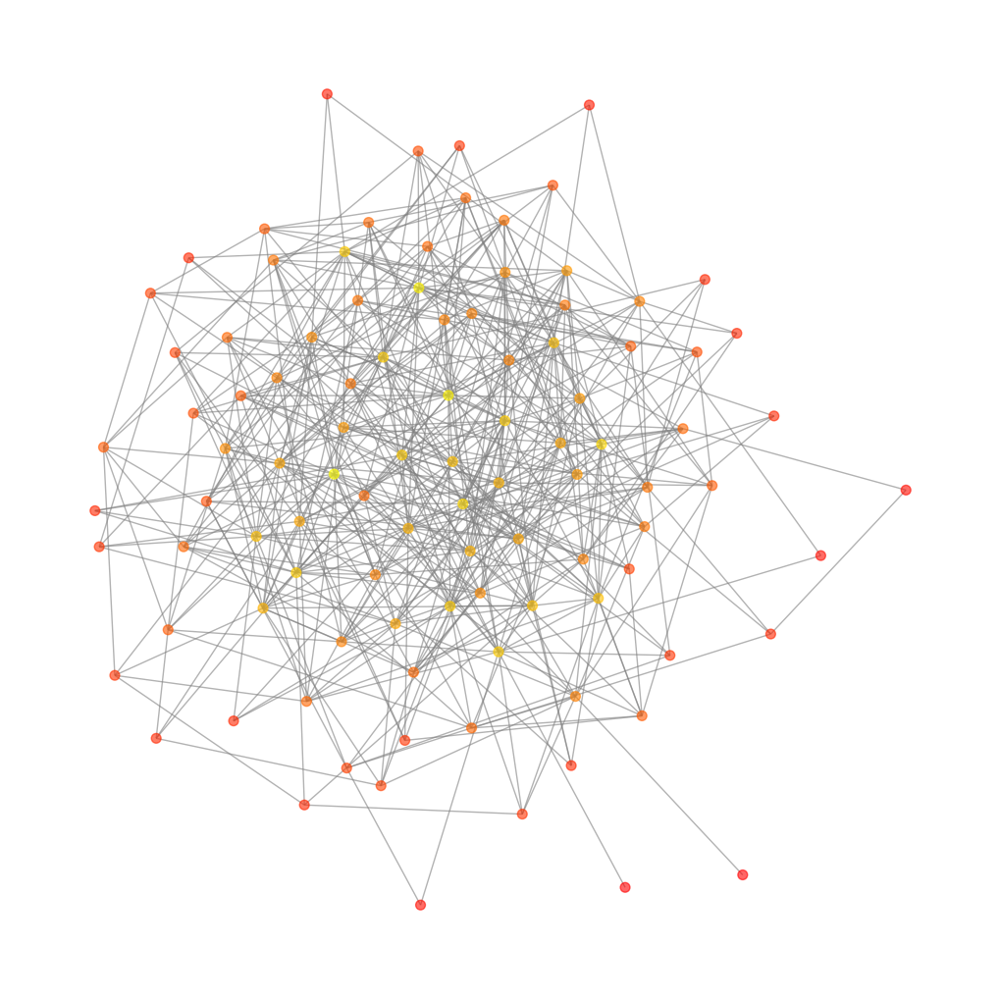

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta-7.498374938964844_gamma-0.09044349193572998_ruleMatchingIndex.npy
Target (η, γ): (-8, -0.1)
Found  (η, γ): (-7.498, -0.090)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-7.498_gamma-0.090.png


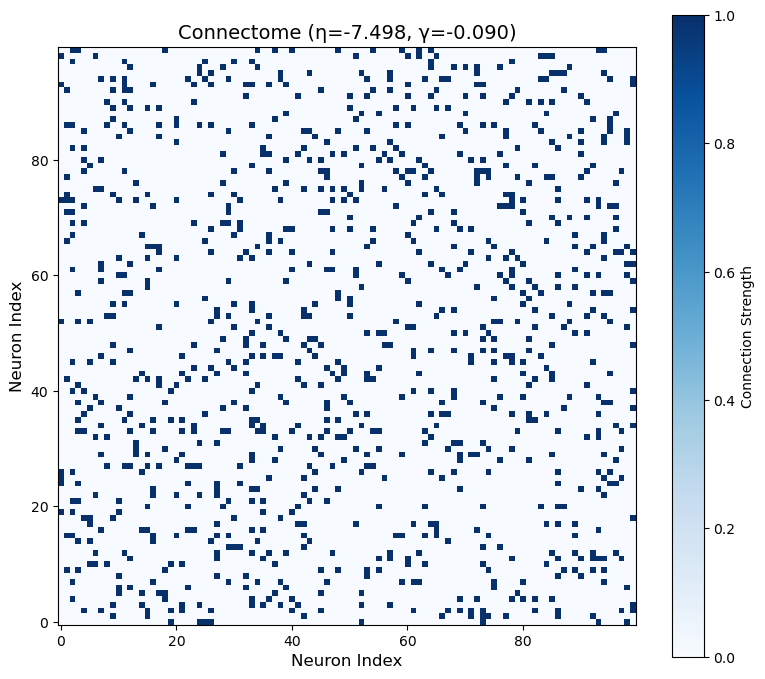

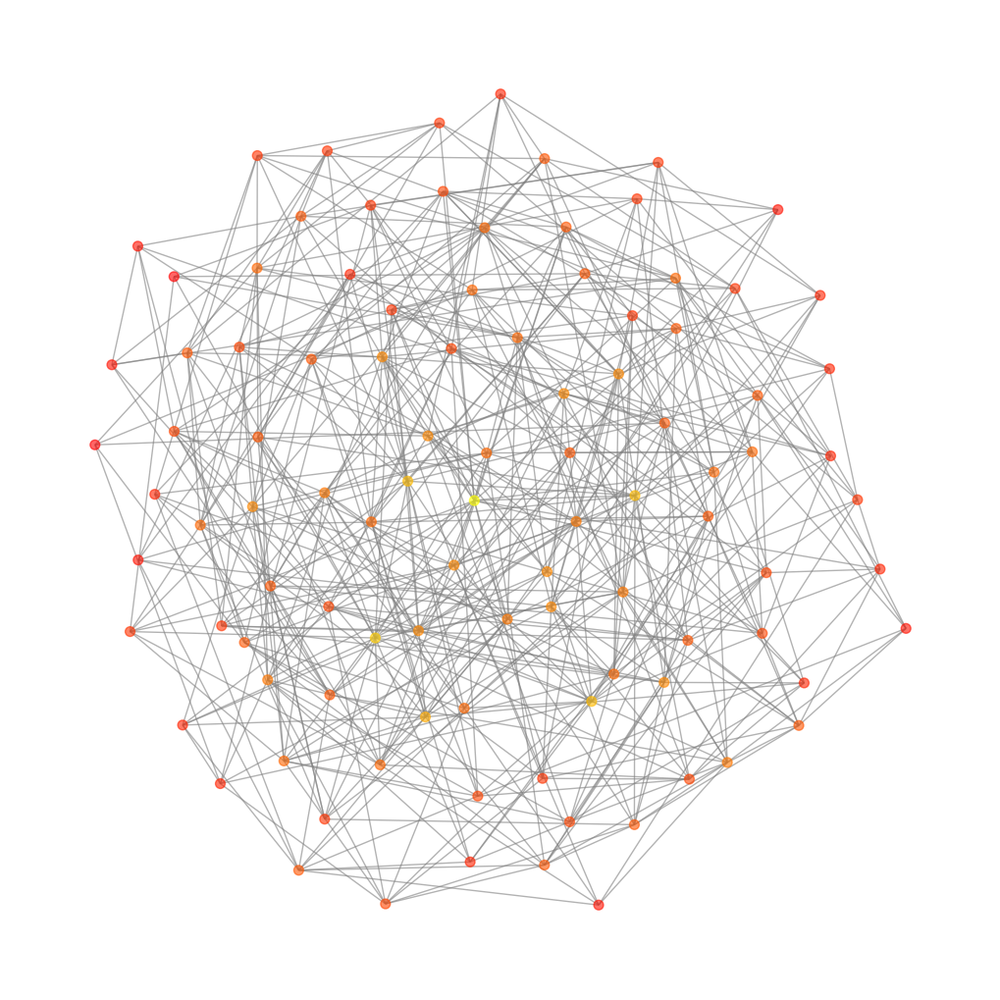

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
Processing block [50:100] with method: spectral
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-7.498_gamma-0.090_spectral_blockwise.png


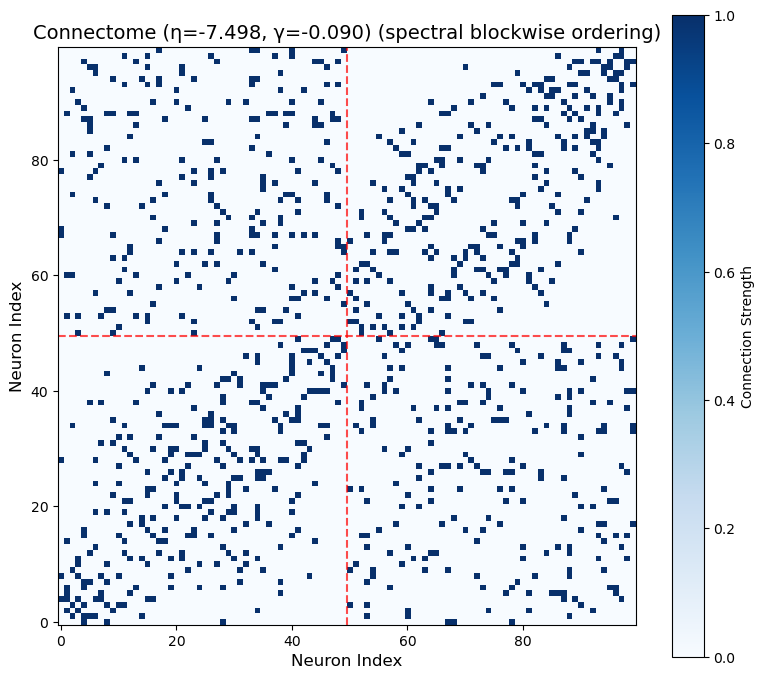

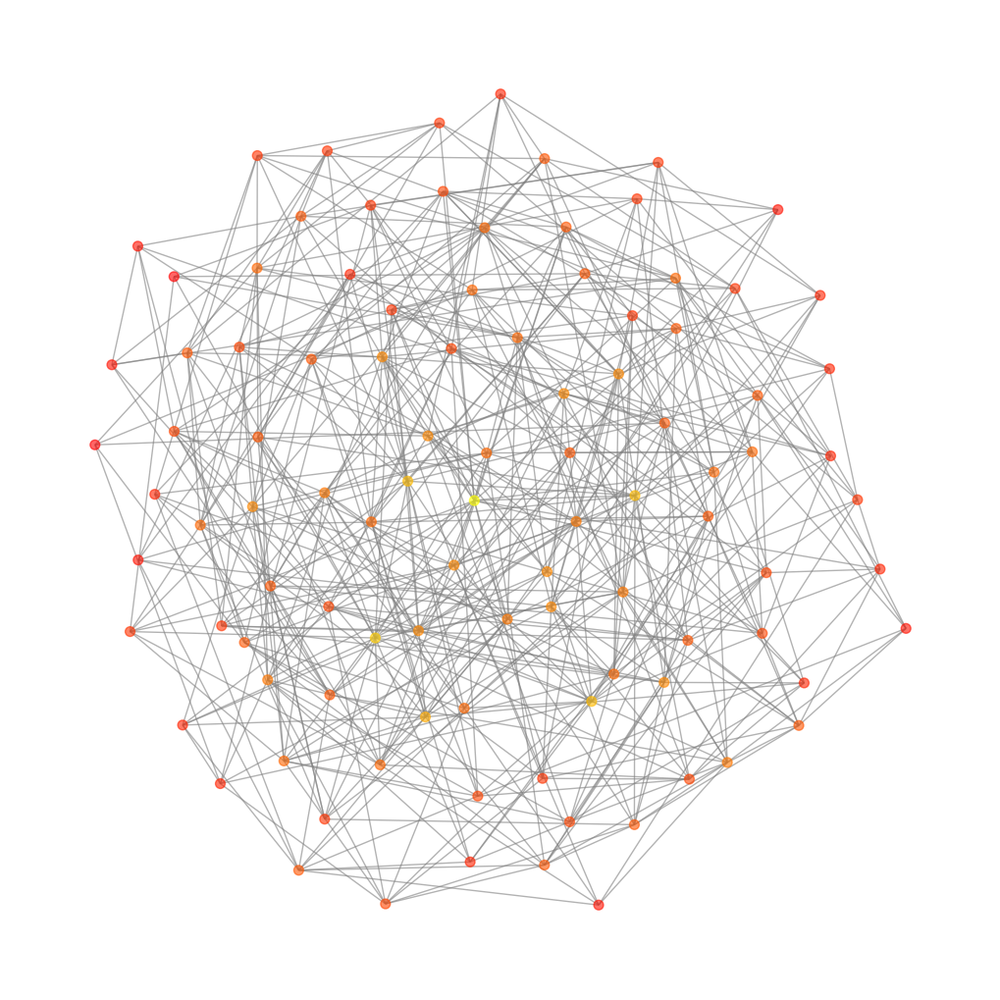

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta-5.252525329589844_gamma0.4020202159881592_ruleMatchingIndex.npy
Target (η, γ): (-5.25, 0.4)
Found  (η, γ): (-5.253, 0.402)
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-5.253_gamma0.402.png


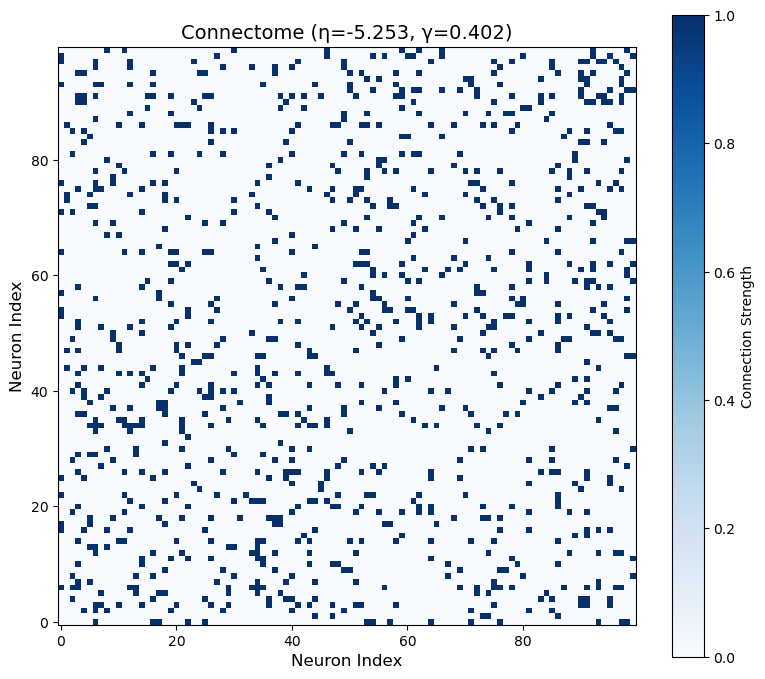

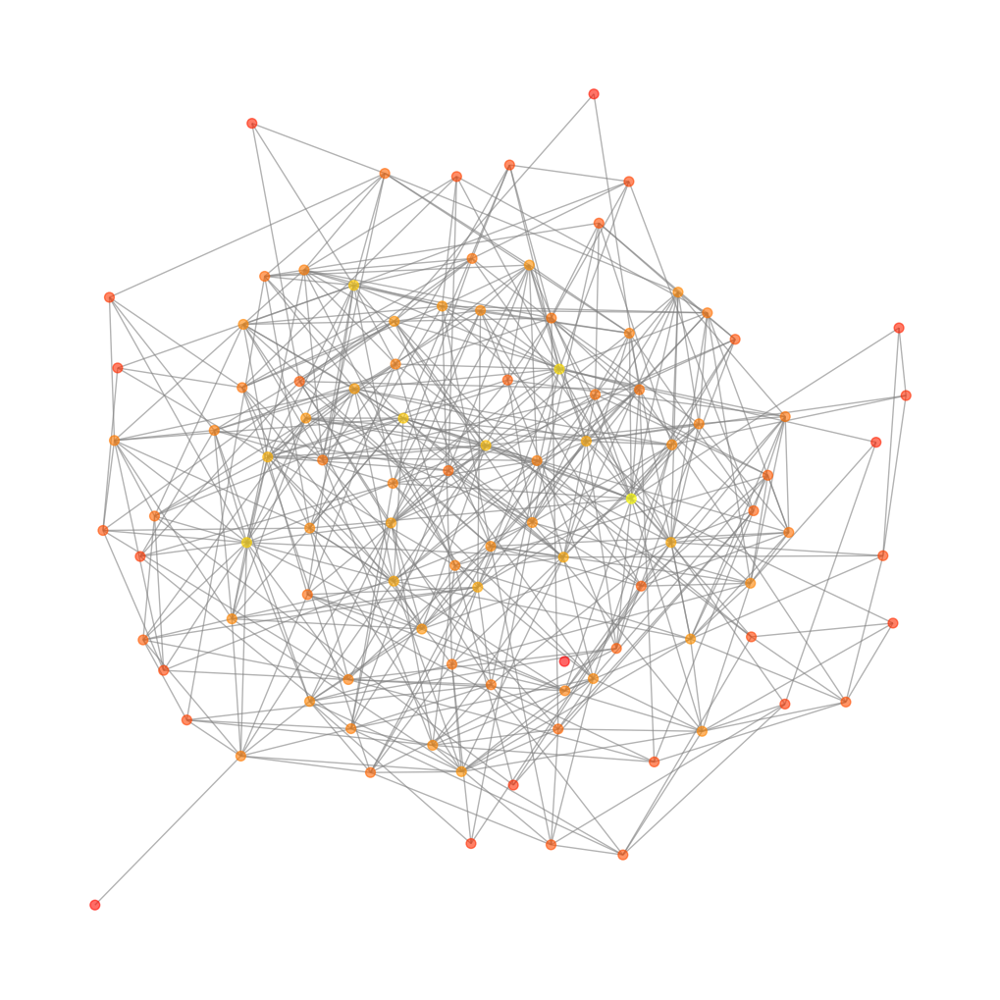

Reordering connectome using block-wise method: spectral
Processing block [0:50] with method: spectral
Processing block [50:100] with method: spectral
  Block [50:100] is disconnected, using degree ordering
Plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/connectome_plots/adjacency_matrix_connectome_eta-5.253_gamma0.402_spectral_blockwise.png


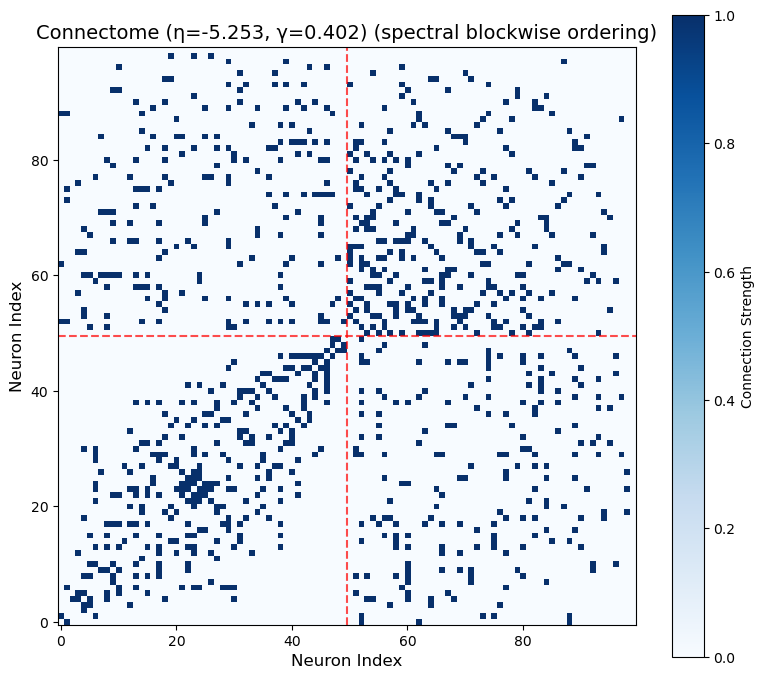

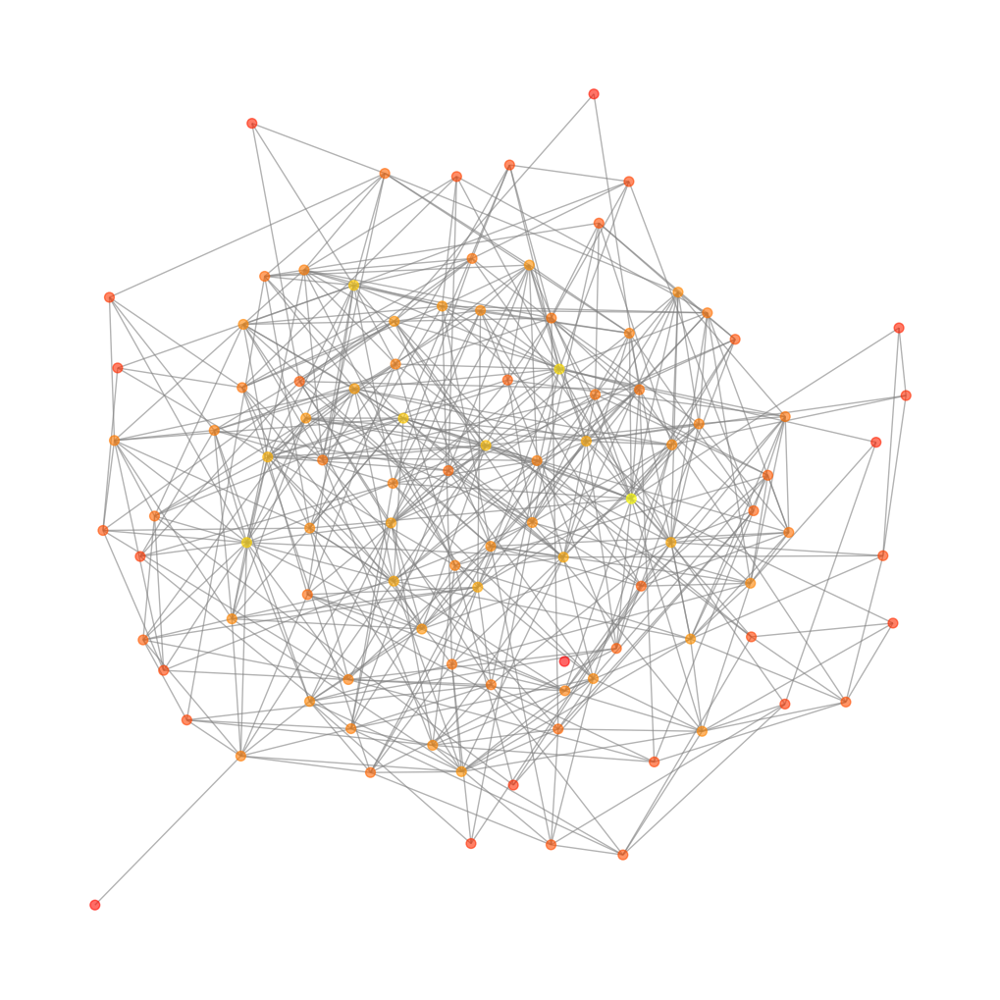

In [4]:
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0")
data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
data_dir.mkdir(parents=True, exist_ok=True)

interesting_eta_and_gamma_combinations = [
    [-8, 1],  
    [3, 1], 
    [0, 1.8],
    [3, -0.1], 
    [-8, -0.1],
    [-5.25, 0.4],
    
    # [-3, 0.1],
    # [-1, 0.5],
    # [-6, 0.5],
    # [-6, -0.1],
    # [-3.75, 0.5],
    # [-1, -0.15],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'  # Change this to experiment with different orderings

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    # Plot original (unordered) connectome
    save_path = plot_connectome_blockwise(connectome, found_eta, found_gamma, data_dir, 
                               save_subdir="connectome_plots",
                               cluster_method=None)
    
    # Plot clustered connectome
    plot_connectome_blockwise(connectome, found_eta, found_gamma, data_dir, 
                   save_subdir="connectome_plots",
                   cluster_method=clustering_method)
    
    # Optional: Create comparison plot of all ordering methods
    # compare_orderings(connectome, found_eta, found_gamma, data_dir)
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)

import pandas as pd
df_interesting_eta_and_gamma_combinations = pd.DataFrame(
    interesting_eta_and_gamma_combinations, 
    columns=["eta", "gamma", "found_eta", "found_gamma"], 
    index=None
)
df_interesting_eta_and_gamma_combinations.to_csv(save_path / "evaluated_eta_and_gamma_combinations.csv")

In [5]:

# # if __name__ == "__main__":
# #     parser = argparse.ArgumentParser(description="Find and plot the closest connectome.")
# #     parser.add_argument("data_dir", type=str, help="Path to the folder containing .npy files.")
# #     parser.add_-argument("--eta", type=float, required=True, help="Target eta value.")
# #     parser.add_argument("--gamma", type=float, required=True, help="Target gamma value.")
# #     parser.add_argument("--save_subdir", type=str, default="connectome_plots", 
# #                         help="Subdirectory name to save plots in.")
    
# #     args = parser.parse_args()
    
# #     find_and_plot_closest_connectome(args.eta, args.gamma, args.data_dir, args.save_subdir)

# data_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/23_testing_4_KS_folders/all_generated_networks"
# save_subdir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/23_testing_4_KS_folders/all_generated_networks/"


# interesting_eta_and_gamma_combinations = [ 
#     [-3, 0.1], 
#     [-1, 0.5], 
#     [-6, 0.5], 
#     [-6, -0.1], 
#     [-3.75, 0.5], 
#     [-1, -0.15], 
    
# ]

# for parameter_combination in interesting_eta_and_gamma_combinations: 
#     target_eta = parameter_combination[0]
#     target_gamma = parameter_combination[1]
    
#     found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
#     save_path = plot_connectome(connectome, found_eta, found_gamma, data_dir, save_subdir="connectome_plots")
    
#     # plot_kamada_kawai(connectome=connectome)
    
#     parameter_combination.append(found_eta)
#     parameter_combination.append(found_gamma)
    


# import pandas as pd 

# df_interesting_eta_and_gamma_combinations = pd.DataFrame(interesting_eta_and_gamma_combinations, columns=["eta", "gamma", "found_eta", "found_gamma"], index=None)
# df_interesting_eta_and_gamma_combinations.to_csv(save_path / "evaluated_eta_and_gamma_combinations.csv")


In [6]:
# from 
    
# path_to_experiment = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/23_testing_4_KS_folders") # /all_generated_networks")
# result_folder = path_to_experiment / "connectome_plots"
# evaluated_combinations_path = result_folder / "evaluated_eta_and_gamma_combinations.csv"


# plot_landscape_with_points_of_visualized_connectomes(path_to_experiment=path_to_experiment)


In [7]:
from kayson_utils import brain_plotter
import numpy as np
from matplotlib import pyplot as plt

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [8]:
data = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed/connectomes_downsampled_to_50/AsianOtter.npy")
coords = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed/coords_downsampled_to_50/AsianOtter.npy")

# Add dimension to data 
# data = data[np.newaxis, :, :]  
data = data.sum(axis=0)

data.shape, coords.shape

((100,), (100, 3))

AttributeError: 'Axes' object has no attribute 'view_init'

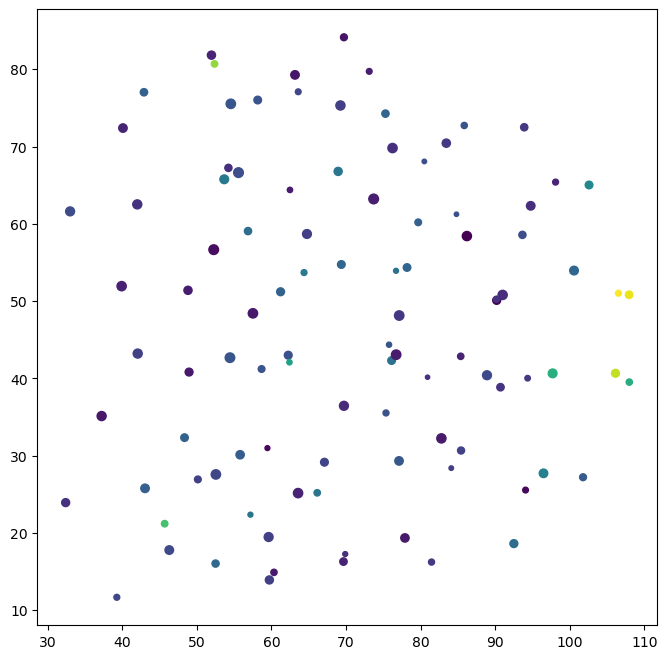

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
brain_plotter(data, coords, axis=ax)

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta-7.498466491699219_gamma0.9603278636932373_ruleMatchingIndex.npy
Target (η, γ): (-8, 1)
Found  (η, γ): (-7.498, 0.960)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta2.4977245330810547_gamma0.9309005737304688_ruleMatchingIndex.npy
Target (η, γ): (3, 1)
Found  (η, γ): (2.498, 0.931)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/generated_networks
Closest file found: net_eta0.009938240051269531_gamma0.18696799874305725_ruleMatchingIndex.npy
Target (η, γ): (0, 0.18)
Found  (η, γ): (0.010, 0.187)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/7

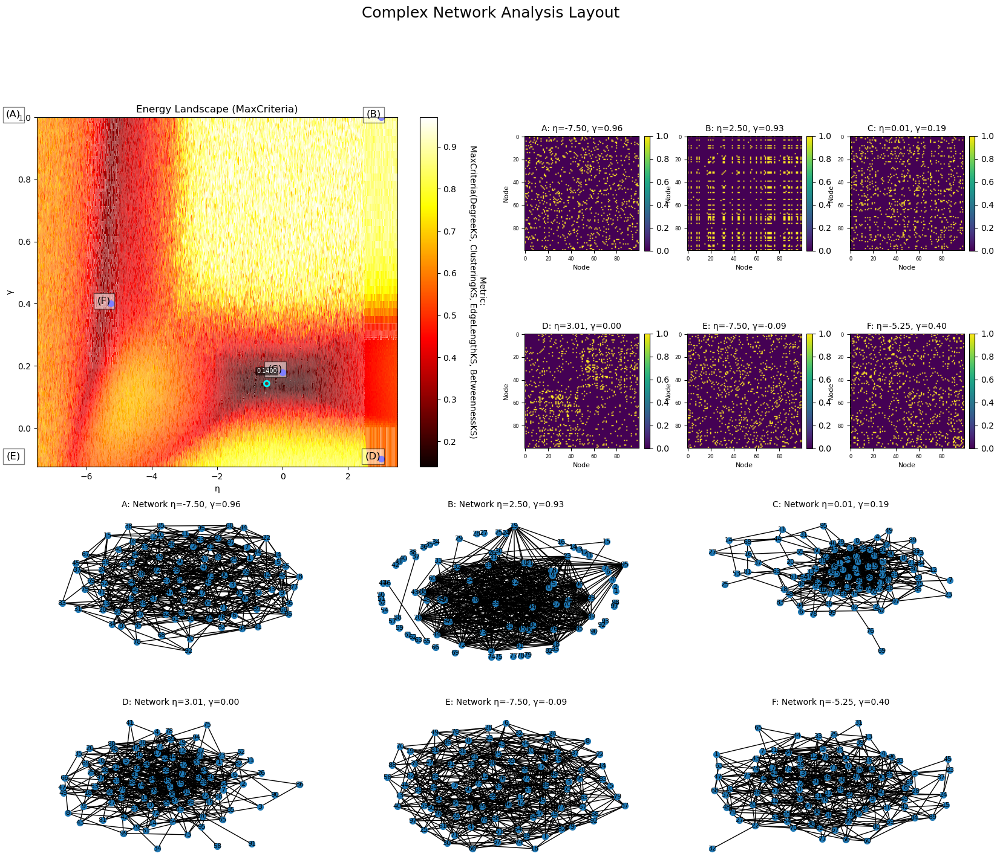

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import numpy as np

base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0")
data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
data_dir.mkdir(parents=True, exist_ok=True)

interesting_eta_and_gamma_combinations = [
    [-8, 1],  
    [3, 1], 
    [0, 0.18],
    [3, -0.1], 
    [-8, -0.1],
    [-5.25, 0.4],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    connectomes.append(connectome)
    params.append((found_eta, found_gamma))
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)

# Create the complex figure layout
fig = plt.figure(figsize=(20, 16))

# Define the grid: 4 rows, 6 columns
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)

#  a a a b c d 
#  a a a h i j    
#  k k l l m m

# Row 1 & 2: a a a (spans both rows) | b c d (row 1) and e f g (row 2)
ax_a = fig.add_subplot(gs[0:2, 0:3])  # a spans 2 rows and 3 columns
ax_b = fig.add_subplot(gs[0, 3])      # b
ax_c = fig.add_subplot(gs[0, 4])      # c
ax_d = fig.add_subplot(gs[0, 5])      # d
ax_e = fig.add_subplot(gs[1, 3])      # e
ax_f = fig.add_subplot(gs[1, 4])      # f
ax_g = fig.add_subplot(gs[1, 5])      # g

# Row 3: hh | ii | jj (each spans 2 columns)
ax_hh = fig.add_subplot(gs[2, 0:2])  # hh spans 2 columns
ax_ii = fig.add_subplot(gs[2, 2:4])  # ii spans 2 columns
ax_jj = fig.add_subplot(gs[2, 4:6])  # jj spans 2 columns

# Row 4: kk | ll | mm (each spans 2 columns)
ax_kk = fig.add_subplot(gs[3, 0:2])  # kk spans 2 columns
ax_ll = fig.add_subplot(gs[3, 2:4])  # ll spans 2 columns
ax_mm = fig.add_subplot(gs[3, 4:6])  # mm spans 2 columns




# Plot MaxCriteria metric landscape in 'a' plots using the visualizer
from src.visualization.energy_and_mc_landscape import PipelineVisualizer
import pandas as pd

# Load the metrics data
metrics_csv_path = base_path / "all_metrics_for_70_mix_and_match_animal_0.csv"
gnm_results_df = pd.read_csv(metrics_csv_path, index_col=False)

# Prepare data for MaxCriteria metric
df = gnm_results_df.copy()
df["eta"] = pd.to_numeric(df["eta"], errors='coerce')
df["gamma"] = pd.to_numeric(df["gamma"], errors='coerce')

# Find the MaxCriteria column
metric_col_name = next(col for col in df.columns if "MaxCriteria" in col)
df[metric_col_name] = pd.to_numeric(df[metric_col_name], errors='coerce')
df = df.dropna(subset=['eta', 'gamma', metric_col_name])

# Initialize visualizer
visualizer = PipelineVisualizer()

# # Plot on ax_a1 (keeping ax_a2 for potential additional content)
visualizer.plot_metric_landscape_voronoi(
    df, 
    title="Energy Landscape (MaxCriteria)",
    metric_name=metric_col_name,
    savepath=None,
    dot_color="steelblue", 
    eta_span=None, 
    gamma_span=None,
    show=False,
    show_dots=False,
    annotate_extremes=True,
    estimated_indiv_connectomes=None,
    ax=ax_a # Pass the axis to plot on
)

# Scatter interesting eta and gamma combinations onto the landscape
ax_a.scatter(
    [combo[0] for combo in interesting_eta_and_gamma_combinations],
    [combo[1] for combo in interesting_eta_and_gamma_combinations],
    color='blue',
    s=50,
    label='Selected Combinations'
)
# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for combo, label in zip(interesting_eta_and_gamma_combinations, labels):
    ax_a.text(combo[0], combo[1], f'({label})', 
              bbox=dict(facecolor='white', alpha=0.5), 
              color='black', fontsize=12, ha='right')




# Keep ax_a2 empty or use for additional info
# ax_a2.text(0.5, 0.5, 'Plot A (empty)', ha='center', va='center', fontsize=16)
# ax_a2.axis('off')


# Plot adjacency matrices in b, c, d, e, f, g
matrix_axes = [ax_b, ax_c, ax_d, ax_e, ax_f, ax_g]
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, (ax, label) in enumerate(zip(matrix_axes, labels)):
    connectome = connectomes[idx]
    im = ax.imshow(connectome, cmap='viridis', aspect='equal')
    ax.set_title(f'{label}: η={params[idx][0]:.2f}, γ={params[idx][1]:.2f}', fontsize=10)
    ax.set_xlabel('Node', fontsize=8)
    ax.set_ylabel('Node', fontsize=8)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# # Leave hh, ii, jj empty for now
# for ax, label in [(ax_hh, 'hh'), (ax_ii, 'ii'), (ax_jj, 'jj')]:
#     ax.text(0.5, 0.5, f'Plot {label} (empty)', ha='center', va='center', fontsize=14)
#     ax.axis('off')




# Plot network visualizations in kk, ll, mm (use networkx for the graphs, e.g., Kamada-Kawai layout)
# Using first 3 networks as examples
network_axes = [ax_hh, ax_ii, ax_jj, ax_kk, ax_ll, ax_mm]
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, (ax, label) in enumerate(zip(network_axes, labels)):
    # Plot network visualization here
    # For now, showing a placeholder - replace with your actual network plotting function
    connectome = connectomes[idx]
    G = nx.from_numpy_array(connectome)
    # pos = nx.kamada_kaway_layout(G)
    nx.draw(G, pos=nx.kamada_kawai_layout(G),  ax=ax, with_labels=True, node_size=50, font_size=8) 
    ax.set_title(f'{label}: Network η={params[idx][0]:.2f}, γ={params[idx][1]:.2f}', fontsize=10)
    ax.set_xlabel('Node', fontsize=8)
    ax.set_ylabel('Node', fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle('Complex Network Analysis Layout', fontsize=18, y=0.995)

# Save the figure
save_path = save_dir / "complex_subplot_layout.pdf"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved complex plot to: {save_path}")

# Save parameter combinations
import pandas as pd
df_interesting_eta_and_gamma_combinations = pd.DataFrame(
    interesting_eta_and_gamma_combinations, 
    columns=["eta", "gamma", "found_eta", "found_gamma"], 
    index=None
)
csv_path = save_dir / "evaluated_eta_and_gamma_combinations.csv"
df_interesting_eta_and_gamma_combinations.to_csv(csv_path)
print(f"Saved parameters to: {csv_path}")

plt.show()

NameError: name 'connectomes' is not defined

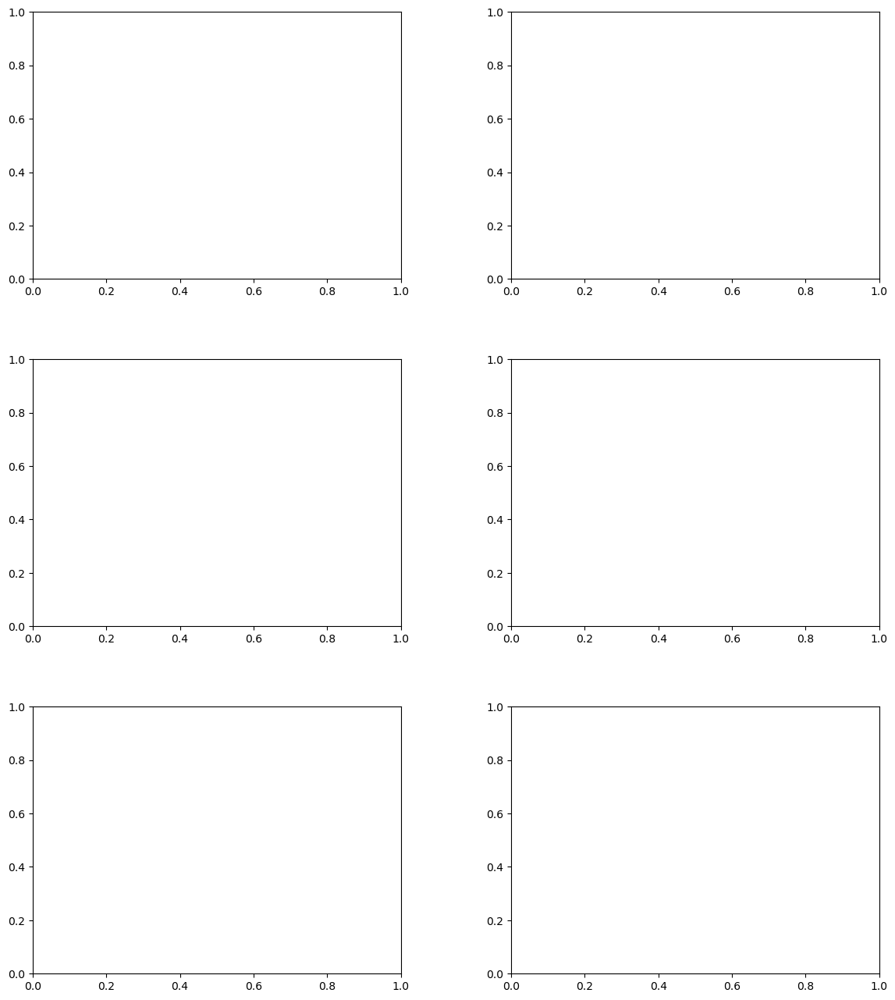

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Create figure with 3 rows, 2 columns layout
fig = plt.figure(figsize=(14, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# Create 6 subplots in a 3x2 grid
axes = [
    fig.add_subplot(gs[0, 0]),  # A - top left
    fig.add_subplot(gs[0, 1]),  # B - top right
    fig.add_subplot(gs[1, 0]),  # C - middle left
    fig.add_subplot(gs[1, 1]),  # D - middle right
    fig.add_subplot(gs[2, 0]),  # E - bottom left
    fig.add_subplot(gs[2, 1]),  # F - bottom right
]

labels = ['A', 'B', 'C', 'D', 'E', 'F']

# Plot degree histograms for each network
for idx, (ax, label) in enumerate(zip(axes, labels)):
    connectome = connectomes[idx]
    
    # Calculate degrees (sum of connections for each node)
    degrees = np.sum(connectome > 0, axis=1)  # Binary degrees (number of connections)
    # Or use weighted degrees:
    # degrees = np.sum(connectome, axis=1)
    
    # Plot histogram
    ax.hist(degrees, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'{label}: η={params[idx][0]:.2f}, γ={params[idx][1]:.2f}', fontsize=12)
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    
    # Add mean degree as vertical line
    mean_degree = np.mean(degrees)
    ax.axvline(mean_degree, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_degree:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Degree Distribution Analysis', fontsize=16, y=0.995)

# Save the figure
save_path = save_dir / "degree_histograms.pdf"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved degree histograms to: {save_path}")

plt.tight_layout()
plt.show()